In [1]:
!pip install -q \
  datasets==2.18.0 \
  transformers==4.39.3 \
  tokenizers==0.15.2 \
  accelerate==0.28.0 \
  peft==0.10.0 \
  soundfile \
  jiwer \
  pyarrow_hotfix \
  --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/134.8 kB ? eta -:--:--

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 4.4 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 17.5 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━ 5.0/8.8 MB 149.2 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 8.8/8.8 MB 176.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/3.6 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.1/290.1 kB 19.5 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 16.6 MB/s eta 0:00:00


In [2]:
!pip install evaluate
!pip install rapidfuzz

INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/116.3 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 13.8 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 12.2 MB/s eta 0:00:00


  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.10.0


...

      Successfully uninstalled multiprocess-0.70.18


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.39.3 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/3.2 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 3.2/3.2 MB 49.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.5 MB/s eta 0:00:00


In [3]:
import torch
from datasets import load_dataset, Audio
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
import evaluate
from jiwer import process_words
import numpy as np
import pandas as pd

2026-02-28 20:40:25.101899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772311225.324268      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772311225.387168      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772311225.927148      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772311225.927197      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772311225.927200      24 computation_placer.cc:177] computation placer alr

In [4]:
dataset = load_dataset(
    "iamTangsang/OpenSLR54-Nepali-ASR",
    split="train",
    streaming=True
)

test_dataset = load_dataset(
    "iamTangsang/OpenSLR54-Nepali-ASR",
    split="test",
    streaming=True
)

dataset = dataset.cast_column("utterance", Audio(sampling_rate=16000))
test_dataset = test_dataset.cast_column("utterance", Audio(sampling_rate=16000))

In [5]:
dataset.features

{'utterance_id': Value(dtype='string', id=None),
 'speaker_id': Value(dtype='string', id=None),
 'utterance': Audio(sampling_rate=16000, mono=True, decode=True, id=None),
 'transcription': Value(dtype='string', id=None),
 'num_frames': Value(dtype='int32', id=None)}

In [6]:
processor = WhisperProcessor.from_pretrained("openai/whisper-small")

model = WhisperForConditionalGeneration.from_pretrained(
    "openai/whisper-small"
)

model.config.forced_decoder_ids = None
model.config.suppress_tokens = []

model.generation_config.language = "ne"
model.generation_config.task = "transcribe"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

In [7]:
def prepare(batch):
    audio = batch["utterance"]

    batch["input_features"] = processor.feature_extractor(
        audio["array"],
        sampling_rate=audio["sampling_rate"]
    ).input_features[0]

    batch["labels"] = processor.tokenizer(
        batch["transcription"]
    ).input_ids

    return batch

train_dataset = dataset.map(prepare, remove_columns=dataset.column_names)
test_dataset = test_dataset.map(prepare, remove_columns=test_dataset.column_names)


In [8]:
import datasets, sys
print(datasets.__version__)
print(sys.version)

2.18.0
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [9]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union

@dataclass
class DataCollatorSpeechSeq2Seq:
    processor: Any

    def __call__(self, features):
        input_features = [{"input_features": f["input_features"]} for f in features]
        label_features = [{"input_ids": f["labels"]} for f in features]

        batch = self.processor.feature_extractor.pad(
            input_features, return_tensors="pt"
        )

        labels_batch = self.processor.tokenizer.pad(
            label_features, return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )

        batch["labels"] = labels
        return batch

data_collator = DataCollatorSpeechSeq2Seq(processor)


In [10]:
# Load the metrics
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

In [11]:
def compute_metrics(pred):
    pred_ids = pred.predictions
    label_ids = pred.label_ids

    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id

    preds = processor.tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    refs = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    wer = wer_metric.compute(predictions=preds, references=refs)
    cer = cer_metric.compute(predictions=preds, references=refs)

    measures = process_words(refs, preds)

    avg_len = np.mean([len(p.split()) for p in preds])

    return {
        "wer": wer,
        "cer": cer,
        "mer": measures.mer,
        "wil": measures.wil,
        "wip": measures.wip,
        "sub_rate": measures.substitutions / measures.hits, 
        "del_rate": measures.deletions / measures.hits,
        "ins_rate": measures.insertions / measures.hits,
        "avg_pred_length": avg_len,
    }



In [12]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./whisper-nepali",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    warmup_steps=500,
    max_steps=1000,              # Change this to 1000 for the first run, 2000 for the second, etc.
    fp16=True,
    gradient_checkpointing=True,
    evaluation_strategy="steps",
    eval_steps=250,              # More frequent evaluation for shorter runs
    save_steps=250,              # Ensure a checkpoint is saved before the 1000-step limit
    logging_steps=50,
    predict_with_generate=True,
    generation_max_length=225,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,
    push_to_hub=False,            # HIGHLY RECOMMENDED: Saves to Hugging Face so you don't lose progress if Kaggle wipes local files
    report_to="none"
)



In [13]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    tokenizer=processor.feature_extractor,
    compute_metrics=compute_metrics,
)


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:432: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches', 'even_batches', 'use_seedable_sampler']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False, even_batches=True, use_seedable_sampler=True)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:463: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [14]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


`use_cache = True` is incompatible with gradient checkpointing. Setting `use_cache = False`...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Wer,Cer,Mer,Wil,Wip,Sub Rate,Del Rate,Ins Rate,Avg Pred Length
250,0.930100,0.819414,0.702779,0.238744,0.670861,0.879437,0.120563,1.721926,0.178322,0.137985,2.797707
500,0.264300,0.248245,0.510580,0.141331,0.493171,0.723917,0.276083,0.833317,0.072458,0.067275,2.829451
750,0.185700,0.192536,0.423351,0.116350,0.412653,0.633669,0.366331,0.601865,0.057681,0.043024,2.812110
1000,0.169400,0.169412,0.394473,0.106149,0.385078,0.599555,0.400445,0.534331,0.053162,0.038730,2.811375


'HTTPSConnectionPool(host='us.gcp.cdn.hf.co', port=443): Read timed out.' thrown while requesting GET https://huggingface.co/datasets/iamTangsang/OpenSLR54-Nepali-ASR/resolve/2382bbae14eb4d04527efd09d1cdd87290337e3d/data/train-00000-of-00012.parquet


...

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}


There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


TrainOutput(global_step=1000, training_loss=0.6416417388916016, metrics={'train_runtime': 42657.3866, 'train_samples_per_second': 0.75, 'train_steps_per_second': 0.023, 'total_flos': 9.23473281024e+18, 'train_loss': 0.6416417388916016, 'epoch': 1.0})

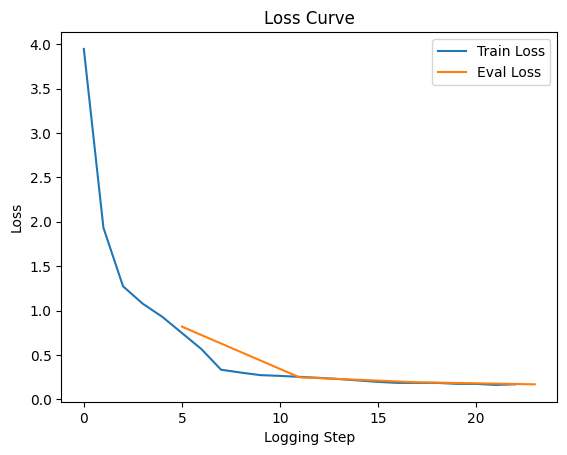

In [15]:
history = trainer.state.log_history
df = pd.DataFrame(history)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["loss"].dropna(), label="Train Loss")
plt.plot(df["eval_loss"].dropna(), label="Eval Loss")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Logging Step")
plt.ylabel("Loss")
plt.show()


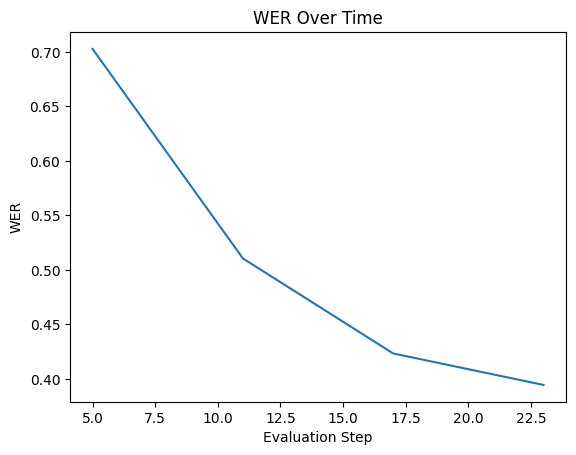

In [16]:
# wer
plt.figure()
plt.plot(df["eval_wer"].dropna())
plt.title("WER Over Time")
plt.xlabel("Evaluation Step")
plt.ylabel("WER")
plt.show()


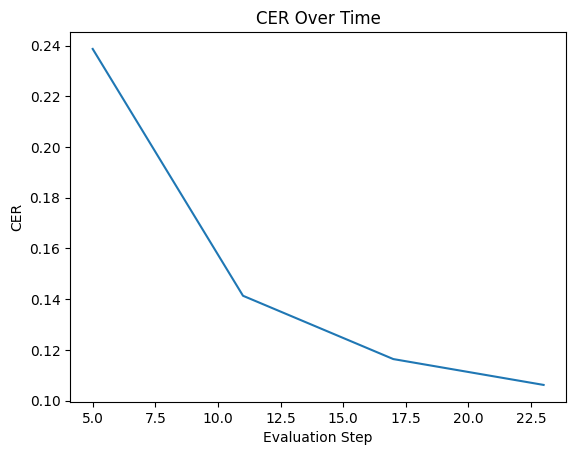

In [17]:
# cer
plt.figure()
plt.plot(df["eval_cer"].dropna())
plt.title("CER Over Time")
plt.xlabel("Evaluation Step")
plt.ylabel("CER")
plt.show()


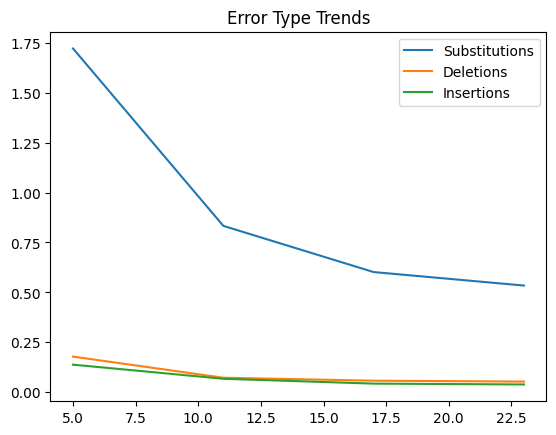

In [18]:
# error type evol
plt.figure()
plt.plot(df["eval_sub_rate"].dropna(), label="Substitutions")
plt.plot(df["eval_del_rate"].dropna(), label="Deletions")
plt.plot(df["eval_ins_rate"].dropna(), label="Insertions")
plt.legend()
plt.title("Error Type Trends")
plt.show()


In [ ]:
# pred len dist
preds = trainer.predict(test_dataset)

pred_text = processor.tokenizer.batch_decode(
    preds.predictions, skip_special_tokens=True
)

lengths = [len(p.split()) for p in pred_text]

plt.figure()
plt.hist(lengths, bins=30)
plt.title("Prediction Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


In [ ]:
# performance vs audio duration
durations = []
refs = []
preds_text = []

for sample, pred in zip(test_dataset.take(200), pred_text):
    durations.append(len(sample["utterance"]["array"]) / 16000)
    refs.append(sample["transcription"])
    preds_text.append(pred)

from jiwer import wer
errors = [wer(r, p) for r, p in zip(refs, preds_text)]

plt.figure()
plt.scatter(durations, errors)
plt.xlabel("Audio Duration (seconds)")
plt.ylabel("WER")
plt.title("WER vs Audio Duration")
plt.show()


In [ ]:
from collections import Counter

errors = []
for r, p in zip(refs, preds_text):
    if r != p:
        errors.append((r, p))

print(errors[:10])

In [ ]:
save_dir = "/kaggle/working/whisper-nepali-final"

trainer.save_model(save_dir)          # saves model + config
processor.save_pretrained(save_dir)   # saves tokenizer + feature extractor